# 🛣️ Projeção de Trajetória GPS na Área Segmentada de Rua (YOLOPv2)

## Objetivo
Para um **frame específico** do vídeo:
1. Segmentar a área da rua usando **YOLOPv2** — retorna `da_seg_mask` (área dirigível) diretamente
2. Extrair o **heading real** do veículo a partir dos timestamps GPS (corrigindo rotação de 90°)
3. Projetar a **rota futura** dentro da máscara da rua via homografia perspectiva
4. A rota sai do capô (parte inferior da imagem) e segue até o canto, curvando conforme o GPS indica

## Sobre o GPX
- O campo `heading` do GPX está **rotacionado 90°** → ignoramos e recalculamos
- O **sentido de movimento** é determinado pela evolução de `timestamp + GPS`
- Usamos os **pontos futuros** ao frame escolhido para traçar a rota que ainda será percorrida

## Dependências
- `YOLOPv2/data/weights/yolopv2.pt` — pesos do modelo (TorchScript `.pt`)
- `torch`, `opencv-python`, `gpxpy`, `pyproj`, `scipy`, `pandas`, `matplotlib`


## ⚙️ Célula 0 — Instalação de dependências

In [36]:
# ============================================================
# CÉLULA 0: Dependências
# ============================================================

import importlib
import subprocess
import sys
from pathlib import Path

REQUIRED_PACKAGES = {
    "torch": "torch",
    "torchvision": "torchvision",
    "gpxpy": "gpxpy",
    "pyproj": "pyproj",
    "scipy": "scipy",
    "cv2": "opencv-python",
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
}

print("Verificando dependências...")

for module, package in REQUIRED_PACKAGES.items():
    try:
        importlib.import_module(module)
    except ImportError:
        print(f"Instalando {package}...")
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", package]
        )

# Importações principais
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from scipy.interpolate import splprep, splev
from scipy.spatial.transform import Rotation

from pyproj import Transformer
from datetime import datetime, timezone, timedelta

# Diretórios importantes
ROOT = Path.cwd()

print("===================================")
print("✅ Ambiente pronto")
print(f"Python : {sys.version.split()[0]}")
print(f"Torch  : {torch.__version__}")
print(f"OpenCV : {cv2.__version__}")
print(f"Numpy  : {np.__version__}")
print("===================================")

Verificando dependências...
✅ Ambiente pronto
Python : 3.14.5
Torch  : 2.12.1+cpu
OpenCV : 4.13.0
Numpy  : 2.5.0


## ⚙️ Célula 1 — Configurações (edite aqui)

In [37]:
# ============================================================
# CÉLULA 1: Configurações
# ============================================================

from pathlib import Path
import os
import numpy as np

# ============================================================
# Arquivos
# ============================================================

ROOT = Path.cwd()

GPX_FILE       = ROOT / "data" / "volta_menor.gpx"
VIDEO_FILE     = ROOT / "data" / "volta_menor.mp4"
OUTPUT_DIR     = ROOT / "output_yolop_frame"
YOLOP_WEIGHTS  = ROOT / "YOLOPv2" / "data" / "weights" / "yolopv2.pt"
CALIB_FILE     = ROOT / "camera_calibration" / "calibracao_camera.json"

OUTPUT_DIR.mkdir(exist_ok=True)

# ============================================================
# Sincronização
# ============================================================

TARGET_FRAME = 692

SYNC_OFFSET_SECONDS = -4.0

LOOK_AHEAD_SECONDS = 20.0

# Corrige diferença entre heading do GPX e eixo longitudinal do veículo
HEADING_CORRECTION_DEG = -90.0

# ============================================================
# YOLOPv2
# ============================================================

DA_THRESHOLD = 0.60

# ============================================================
# Geometria da câmera
# ============================================================

# Altura do centro óptico ao solo (m)
CAMERA_HEIGHT = 1.35


# Roll normalmente é praticamente zero
CAMERA_ROLL_DEG = 0.0

PITCH_DEG = 8.0 
YAW_CAM_DEG = 0.0

pitch = np.deg2rad(PITCH_DEG)
yaw = np.deg2rad(YAW_CAM_DEG)

# ============================================================
# Limites da projeção
# ============================================================

# Ignora pontos muito próximos do veículo
MIN_DISTANCE = 0.75

# Distância máxima desenhada
MAX_DISTANCE = 35.0

# Largura aproximada do corredor
ROAD_WIDTH = 5.0

# Largura do corredor desenhado
CORRIDOR_WIDTH = 2.5

# ============================================================
# Renderização
# ============================================================

ROUTE_COLOR_START = (0,255,100)
ROUTE_COLOR_END   = (0,100,255)

ROUTE_LINE_WIDTH = 8
ROUTE_ALPHA = 0.30

SPLINE_POINTS = 120

# ============================================================
# Debug
# ============================================================

DEBUG = True

print("="*50)
print("Configurações carregadas")
print("="*50)
print(f"Frame               : {TARGET_FRAME}")
print(f"Look Ahead          : {LOOK_AHEAD_SECONDS:.1f} s")
print(f"Heading correction  : {HEADING_CORRECTION_DEG:.1f}°")
print(f"Camera height       : {CAMERA_HEIGHT:.2f} m")
print(f"Camera pitch        : {PITCH_DEG:.1f}°")
print(f"Camera yaw          : {YAW_CAM_DEG:.1f}°")
print(f"Max projection      : {MAX_DISTANCE:.1f} m")
print("="*50)

Configurações carregadas
Frame               : 692
Look Ahead          : 20.0 s
Heading correction  : -90.0°
Camera height       : 1.35 m
Camera pitch        : 8.0°
Camera yaw          : 0.0°
Max projection      : 35.0 m


## ✅ Célula 1.5 — Validação da Sincronização GPS-Vídeo

In [38]:
# ============================================================
# CÉLULA 1.5: Diagnóstico da sincronização GPS ↔ Vídeo
# ============================================================

from datetime import datetime, timezone, timedelta
import gpxpy
import cv2

print("="*70)
print("DIAGNÓSTICO DA SINCRONIZAÇÃO")
print("="*70)

# ------------------------------------------------------------
# Ler vídeo
# ------------------------------------------------------------

cap = cv2.VideoCapture(str(VIDEO_FILE))

if not cap.isOpened():
    raise RuntimeError(f"Não foi possível abrir {VIDEO_FILE}")

fps = cap.get(cv2.CAP_PROP_FPS)
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

duration = n_frames / fps

cap.release()

# ------------------------------------------------------------
# Ler GPX
# ------------------------------------------------------------

with open(GPX_FILE, "r") as f:
    gpx = gpxpy.parse(f)

pts = gpx.tracks[0].segments[0].points

gps_start = pts[0].time.replace(tzinfo=timezone.utc)
gps_end   = pts[-1].time.replace(tzinfo=timezone.utc)

gps_duration = (gps_end-gps_start).total_seconds()

# ------------------------------------------------------------
# Tempo do vídeo
# ------------------------------------------------------------

video_start = gps_start + timedelta(seconds=SYNC_OFFSET_SECONDS)

frame_time_video = TARGET_FRAME / fps

frame_time_gps = frame_time_video + SYNC_OFFSET_SECONDS

frame_timestamp = gps_start + timedelta(seconds=frame_time_gps)

# ------------------------------------------------------------
# Impressão
# ------------------------------------------------------------

print(f"Vídeo")
print(f"  Arquivo : {VIDEO_FILE}")
print(f"  FPS     : {fps:.2f}")
print(f"  Frames  : {n_frames}")
print(f"  Duração : {duration:.2f}s")

print()

print(f"GPX")
print(f"  Arquivo : {GPX_FILE}")
print(f"  Início  : {gps_start}")
print(f"  Final   : {gps_end}")
print(f"  Duração : {gps_duration:.2f}s")

print()

print("Sincronização")
print(f"  Offset vídeo : {SYNC_OFFSET_SECONDS:+.2f}s")
print(f"  Vídeo inicia : {video_start}")
print(f"  GPS inicia   : {gps_start}")

print()

print(f"Frame alvo")
print(f"  Frame        : {TARGET_FRAME}")
print(f"  Tempo vídeo  : {frame_time_video:.2f}s")
print(f"  Tempo GPS    : {frame_time_gps:.2f}s")
print(f"  Timestamp    : {frame_timestamp}")

print()

# ------------------------------------------------------------
# Validação
# ------------------------------------------------------------

if frame_time_gps < 0:
    print("❌ O frame escolhido ocorre antes do início do GPX.")

elif frame_time_gps > gps_duration:
    print("❌ O frame escolhido ocorre após o fim do GPX.")

else:
    print("✅ O frame possui correspondência no GPX.")

print("="*70)

DIAGNÓSTICO DA SINCRONIZAÇÃO
Vídeo
  Arquivo : c:\Users\Pedro\pibic 26_27\data\volta_menor.mp4
  FPS     : 27.96
  Frames  : 4782
  Duração : 171.03s

GPX
  Arquivo : c:\Users\Pedro\pibic 26_27\data\volta_menor.gpx
  Início  : 2026-06-26 19:38:35+00:00
  Final   : 2026-06-26 19:41:11+00:00
  Duração : 156.00s

Sincronização
  Offset vídeo : -4.00s
  Vídeo inicia : 2026-06-26 19:38:31+00:00
  GPS inicia   : 2026-06-26 19:38:35+00:00

Frame alvo
  Frame        : 692
  Tempo vídeo  : 24.75s
  Tempo GPS    : 20.75s
  Timestamp    : 2026-06-26 19:38:55.750106+00:00

✅ O frame possui correspondência no GPX.


## 📡 Célula 2 — Carregar GPX e calcular heading real

In [39]:
# ============================================================
# CÉLULA 2: Carregar GPX → ENU → Heading suavizado
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import gpxpy

from pyproj import Transformer
from scipy.signal import savgol_filter

print("="*60)
print("Carregando GPX")
print("="*60)

# ------------------------------------------------------------
# Leitura GPX
# ------------------------------------------------------------

def load_gpx(path):

    with open(path,"r") as f:
        gpx = gpxpy.parse(f)

    rows=[]

    for tr in gpx.tracks:
        for seg in tr.segments:
            for p in seg.points:

                t=p.time

                if t is not None and t.tzinfo is None:
                    t=t.replace(tzinfo=timezone.utc)

                rows.append(
                    dict(
                        lat=p.latitude,
                        lon=p.longitude,
                        alt=p.elevation if p.elevation is not None else 0.0,
                        time=t
                    )
                )

    return pd.DataFrame(rows)

df_gps=load_gpx(GPX_FILE)

print(f"{len(df_gps)} pontos carregados.")

# ------------------------------------------------------------
# Tempo
# ------------------------------------------------------------

t0=df_gps.time.iloc[0]

df_gps["t_sec"]=[
    (t-t0).total_seconds()
    for t in df_gps.time
]

# ------------------------------------------------------------
# Conversão para UTM (apenas uma vez)
# ------------------------------------------------------------

transformer=Transformer.from_crs(
    "EPSG:4326",
    "EPSG:32723",
    always_xy=True
)

E,N=transformer.transform(
    df_gps.lon.values,
    df_gps.lat.values
)

E-=E[0]
N-=N[0]

df_gps["east"]=E
df_gps["north"]=N
df_gps["up"]=df_gps.alt.values-df_gps.alt.values[0]

# ------------------------------------------------------------
# Suavização da trajetória
# ------------------------------------------------------------

if len(df_gps)>11:

    win=min(21,len(df_gps)//2*2+1)

    df_gps["east_smooth"]=savgol_filter(
        df_gps.east,
        window_length=win,
        polyorder=2
    )

    df_gps["north_smooth"]=savgol_filter(
        df_gps.north,
        window_length=win,
        polyorder=2
    )

else:

    df_gps["east_smooth"]=df_gps.east
    df_gps["north_smooth"]=df_gps.north

# ------------------------------------------------------------
# Heading usando derivada da trajetória suavizada
# ------------------------------------------------------------

dE = np.gradient(df_gps.east_smooth)
dN = np.gradient(df_gps.north_smooth)

heading = np.arctan2(dE, dN)

heading = np.unwrap(heading)

df_gps["heading_rad"] = heading

# ------------------------------------------------------------
# Vetor tangente (será usado na projeção)
# ------------------------------------------------------------

norm=np.sqrt(dE*dE+dN*dN)

norm[norm<1e-6]=1

df_gps["tx"]=dE/norm
df_gps["ty"]=dN/norm

# ------------------------------------------------------------
# Curvatura aproximada
# ------------------------------------------------------------

dHeading=np.gradient(heading)

distance=np.sqrt(dE*dE+dN*dN)

distance[distance<0.05]=0.05

df_gps["curvature"]=dHeading/distance

# ------------------------------------------------------------
# Estatísticas
# ------------------------------------------------------------

print()

print("Trajetória")

print(f"Tempo total : {df_gps.t_sec.max():.1f} s")

print(f"East  : {df_gps.east.min():.2f} -> {df_gps.east.max():.2f}")

print(f"North : {df_gps.north.min():.2f} -> {df_gps.north.max():.2f}")

print()

print("Heading")

for i in range(min(5,len(df_gps))):

    print(
        f"{i:02d}  "
        f"{np.rad2deg(df_gps.heading_rad.iloc[i])%360:6.1f}°"
    )

print()

print("✅ GPX preparado.")

Carregando GPX
94 pontos carregados.

Trajetória
Tempo total : 156.0 s
East  : -164.95 -> 175.41
North : -76.51 -> 370.98

Heading
00   318.5°
01   319.1°
02   320.0°
03   321.0°
04   321.8°

✅ GPX preparado.


## 🔗 Célula 3 — Interpolação GPS → frames do vídeo

In [40]:
# ============================================================
# CÉLULA 3: Interpolação temporal GPX → Frame → Trajetória futura
# ============================================================

from scipy.interpolate import CubicSpline

print("=" * 60)
print("Interpolando trajetória")
print("=" * 60)

# ------------------------------------------------------------
# Abrir vídeo
# ------------------------------------------------------------

cap = cv2.VideoCapture(str(VIDEO_FILE))

if not cap.isOpened():
    raise RuntimeError(f"Não foi possível abrir {VIDEO_FILE}")

FPS = cap.get(cv2.CAP_PROP_FPS)
TOTAL_FRAMES = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

W_img = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H_img = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

cap.set(cv2.CAP_PROP_POS_FRAMES, TARGET_FRAME)

ok, frame_orig = cap.read()

cap.release()

if not ok:
    raise RuntimeError(f"Não foi possível ler o frame {TARGET_FRAME}")

print(f"Vídeo : {W_img}x{H_img}")
print(f"FPS   : {FPS:.2f}")
print(f"Frame : {TARGET_FRAME}/{TOTAL_FRAMES}")

# ------------------------------------------------------------
# Splines temporais
# ------------------------------------------------------------

t = df_gps.t_sec.values

csE = CubicSpline(t, df_gps.east_smooth.values)
csN = CubicSpline(t, df_gps.north_smooth.values)
csH = CubicSpline(t, np.unwrap(df_gps.heading_rad.values))

# ------------------------------------------------------------
# Tempo correspondente ao frame
# ------------------------------------------------------------

t_frame = TARGET_FRAME / FPS + SYNC_OFFSET_SECONDS

if t_frame < t.min() or t_frame > t.max():
    raise RuntimeError(
        f"Frame fora do GPX.\n"
        f"Tempo frame = {t_frame:.2f}s\n"
        f"GPX = [{t.min():.2f},{t.max():.2f}]"
    )

# ------------------------------------------------------------
# Estado atual do veículo
# ------------------------------------------------------------

east_now = float(csE(t_frame))
north_now = float(csN(t_frame))
heading_now = float(csH(t_frame))

frame_row = dict(
    east=east_now,
    north=north_now,
    heading=heading_now,
    t_sec=t_frame
)

print()

print("Estado do veículo")

print(f"East    : {east_now:.2f} m")

print(f"North   : {north_now:.2f} m")

print(f"Heading : {np.rad2deg(heading_now)%360:.1f}°")

# ------------------------------------------------------------
# Trajetória futura
# ------------------------------------------------------------

t_end = min(t_frame + LOOK_AHEAD_SECONDS, t.max())

# Amostragem mais densa perto do veículo
u = np.linspace(0.0, 1.0, 120)

future_times = t_frame + (u**1.5) * (t_end - t_frame)

future_e = csE(future_times)
future_n = csN(future_times)
future_h = csH(future_times)

df_future = pd.DataFrame({
    "t_sec": future_times,
    "east": future_e,
    "north": future_n,
    "heading": future_h
})

# ------------------------------------------------------------
# Coordenadas relativas ao veículo
# ------------------------------------------------------------

de = future_e - east_now
dn = future_n - north_now

c = np.cos(heading_now)
s = np.sin(heading_now)

# Sistema do veículo
# X = frente
# Y = esquerda

df_future["x_vehicle"] = c * dn + s * de
df_future["y_vehicle"] = s * dn + c * de

# Distância acumulada

df_future["distance"] = np.sqrt(
    df_future.x_vehicle**2 +
    df_future.y_vehicle**2
)


df_future["de"] = de
df_future["dn"] = dn


# Manter somente pontos à frente

df_future = df_future[
    (df_future.x_vehicle > MIN_DISTANCE) &
    (df_future.distance < MAX_DISTANCE)
].reset_index(drop=True)

print()

print(f"Trajetória futura: {len(df_future)} pontos")

print(f"Look Ahead : {LOOK_AHEAD_SECONDS:.1f} s")

print(f"Maior distância : {df_future.distance.max():.2f} m")

# ------------------------------------------------------------
# Trajetória completa para debug
# ------------------------------------------------------------

frame_times = np.clip(
    np.arange(TOTAL_FRAMES)/FPS + SYNC_OFFSET_SECONDS,
    t.min(),
    t.max()
)

df_frames = pd.DataFrame({
    "frame": np.arange(TOTAL_FRAMES),
    "east": csE(frame_times),
    "north": csN(frame_times)
})

print()

print("✅ Trajetória preparada.")

Interpolando trajetória
Vídeo : 1080x1920
FPS   : 27.96
Frame : 692/4782

Estado do veículo
East    : -39.72 m
North   : 59.19 m
Heading : 323.8°

Trajetória futura: 40 pontos
Look Ahead : 20.0 s
Maior distância : 34.14 m

✅ Trajetória preparada.


## 🤖 Célula 4 — Segmentação da rua com YOLOPv2

Carregando YOLOPv2
YOLOPv2 carregado em cpu
Executando segmentação...
Cobertura: 10.0%
Maior largura interna: 112.0px


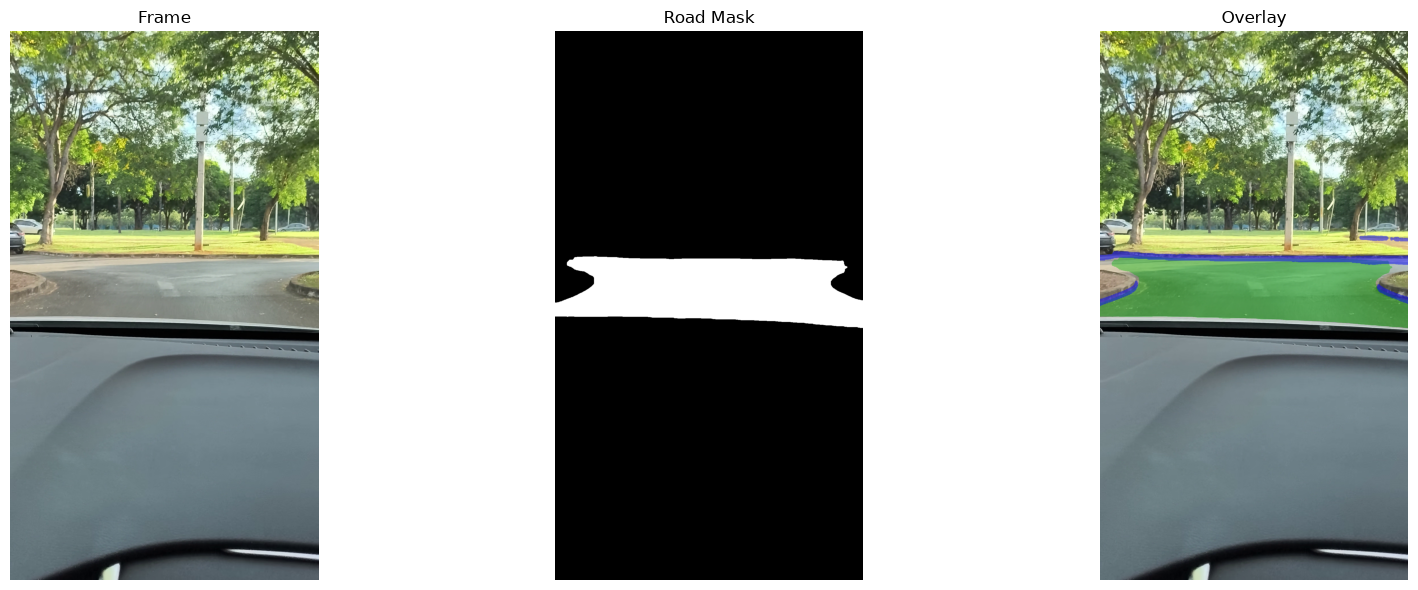


✅ Máscara pronta.


In [41]:
# ============================================================
# CÉLULA 4: YOLOPv2 → Máscara da Área Dirigível
# ============================================================

import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Carregar YOLOPv2
# ------------------------------------------------------------

def load_yolop(weights):

    weights = Path(weights)

    if not weights.exists():
        raise FileNotFoundError(weights)

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    model = torch.jit.load(str(weights), map_location=device)
    model.eval().to(device)

    if device.type == "cuda":
        model.half()

    print(f"YOLOPv2 carregado em {device}")

    return model, device


print("="*60)
print("Carregando YOLOPv2")
print("="*60)

yolop_model, yolop_device = load_yolop(YOLOP_WEIGHTS)

# ------------------------------------------------------------
# Inferência
# ------------------------------------------------------------

def infer_yolop(frame):

    H,W = frame.shape[:2]

    img = cv2.resize(frame,(640,640))

    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    img = torch.from_numpy(img)

    img = img.permute(2,0,1).float()/255.

    img = img.unsqueeze(0).to(yolop_device)

    if yolop_device.type=="cuda":
        img = img.half()

    with torch.no_grad():

        _, seg, lane = yolop_model(img)

    seg = seg[0].float().cpu().numpy()

    lane = lane[0].float().cpu().numpy()

    road = seg[1]

    lane = lane[0]

    road = cv2.resize(
        road,
        (W,H),
        interpolation=cv2.INTER_LINEAR
    )

    lane = cv2.resize(
        lane,
        (W,H),
        interpolation=cv2.INTER_LINEAR
    )

    road = (road>DA_THRESHOLD).astype(np.uint8)*255

    lane = (lane>0.30).astype(np.uint8)*255

    return road,lane

print("Executando segmentação...")

road_mask,lane_mask = infer_yolop(frame_orig)

H_img,W_img = road_mask.shape

# ------------------------------------------------------------
# Limpeza da máscara
# ------------------------------------------------------------

kernel_close = np.ones((15,15),np.uint8)

kernel_open = np.ones((5,5),np.uint8)

road_mask = cv2.morphologyEx(
    road_mask,
    cv2.MORPH_CLOSE,
    kernel_close
)

road_mask = cv2.morphologyEx(
    road_mask,
    cv2.MORPH_OPEN,
    kernel_open
)

# ------------------------------------------------------------
# Manter somente a maior região conectada
# ------------------------------------------------------------

num, labels, stats, _ = cv2.connectedComponentsWithStats(
    road_mask
)

if num>1:

    areas = stats[:,cv2.CC_STAT_AREA]

    idx = np.argmax(areas[1:])+1

    road_mask = np.where(
        labels==idx,
        255,
        0
    ).astype(np.uint8)

# ------------------------------------------------------------
# Preencher pequenos buracos
# ------------------------------------------------------------

road_mask = cv2.medianBlur(road_mask,5)

# ------------------------------------------------------------
# Distância até a borda
# (vamos usar isso para centralizar a trajetória)
# ------------------------------------------------------------

road_distance = cv2.distanceTransform(
    road_mask,
    cv2.DIST_L2,
    5
)

coverage = road_mask.mean()/255*100

print(f"Cobertura: {coverage:.1f}%")

print(f"Maior largura interna: {road_distance.max():.1f}px")

# ------------------------------------------------------------
# Visualização
# ------------------------------------------------------------

overlay = frame_orig.copy()

overlay[road_mask>0] = (
    0.6*overlay[road_mask>0] +
    0.4*np.array([0,180,0])
).astype(np.uint8)

overlay[lane_mask>0] = (
    0.5*overlay[lane_mask>0] +
    0.5*np.array([255,0,0])
).astype(np.uint8)

fig,ax = plt.subplots(
    1,
    3,
    figsize=(18,6)
)

ax[0].imshow(cv2.cvtColor(frame_orig,cv2.COLOR_BGR2RGB))
ax[0].set_title("Frame")
ax[0].axis("off")

ax[1].imshow(road_mask,cmap="gray")
ax[1].set_title("Road Mask")
ax[1].axis("off")

ax[2].imshow(cv2.cvtColor(overlay,cv2.COLOR_BGR2RGB))
ax[2].set_title("Overlay")
ax[2].axis("off")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR/"road_mask.png",
    dpi=150
)

plt.show()

print()

print("✅ Máscara pronta.")

## 📐 Célula 5 — Calibração da homografia (Mundo → Imagem)

Intrínsecos
[[1.47743151e+03 0.00000000e+00 5.40000000e+02]
 [0.00000000e+00 1.50166593e+03 9.60000000e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

Extrínsecos
Pitch : 8.0
Yaw   : 0.0
Altura: 1.35


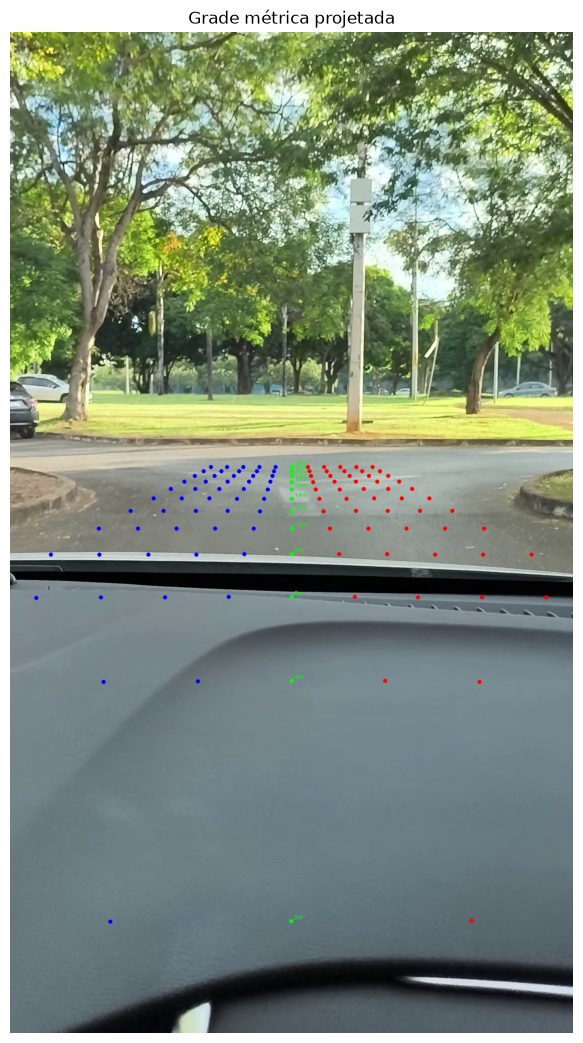

In [45]:
# ============================================================
# CÉLULA 5 - CALIBRAÇÃO DA CÂMERA
# (nova versão)
# ============================================================

import json
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Carregar parâmetros
# ------------------------------------------------------------

with open(CALIB_FILE) as f:
    calib = json.load(f)

K0 = np.array(
    calib["parametros_intrinsecos"]["matriz_camera_mtx"],
    dtype=np.float64
)

dist = np.array(
    calib["parametros_intrinsecos"]["coeficientes_distorcao_dist"],
    dtype=np.float64
)

# resolução usada durante a calibração
W_CAL = 2*K0[0,2]
H_CAL = 2*K0[1,2]

sx = W_img/W_CAL
sy = H_img/H_CAL

K = K0.copy()

K[0,0] *= sx
K[0,2] *= sx

K[1,1] *= sy
K[1,2] *= sy

fx = K[0,0]
fy = K[1,1]
cx = K[0,2]
cy = K[1,2]

print("Intrínsecos")

print(K)

# ------------------------------------------------------------
# Sistema veículo
#
# X = frente
# Y = esquerda
# Z = cima
# ------------------------------------------------------------

pitch = np.deg2rad(PITCH_DEG)
yaw = np.deg2rad(YAW_CAM_DEG)

Rx = np.array([
    [1,0,0],
    [0,np.cos(pitch),-np.sin(pitch)],
    [0,np.sin(pitch), np.cos(pitch)]
])

Ry = np.array([
    [ np.cos(yaw),0,np.sin(yaw)],
    [0,1,0],
    [-np.sin(yaw),0,np.cos(yaw)]
])

# câmera OpenCV:
#
# X direita
# Y baixo
# Z frente
#

R0 = np.array([
    [0,-1,0],
    [0,0,-1],
    [1,0,0]
])

R = Rx @ Ry @ R0

rvec,_ = cv2.Rodrigues(R)

camera_center = np.array([
    [0],
    [0],
    [CAMERA_HEIGHT]
])

tvec = -R @ camera_center

print()
print("Extrínsecos")
print("Pitch :",PITCH_DEG)
print("Yaw   :",YAW_CAM_DEG)
print("Altura:",CAMERA_HEIGHT)

# ------------------------------------------------------------
# projeção vetorizada
# ------------------------------------------------------------

def vehicle_to_image(points):

    """
    points:

    Nx2

    X frente

    Y esquerda

    """

    pts = np.asarray(points,dtype=np.float32)

    if pts.ndim==1:
        pts=pts.reshape(1,-1)

    obj=np.column_stack([
        pts[:,0],
        pts[:,1],
        np.zeros(len(pts))
    ])

    img,_=cv2.projectPoints(
        obj,
        rvec,
        tvec,
        K,
        dist
    )

    return img.reshape(-1,2)

# ------------------------------------------------------------
# teste
# ------------------------------------------------------------

frame_debug=frame_orig.copy()

xs=np.arange(2,26,2)
ys=np.arange(-2.5,2.6,0.5)

for x in xs:

    pts=np.column_stack([
        np.full(len(ys),x),
        ys
    ])

    img=vehicle_to_image(pts)

    for (u,v),y in zip(img,ys):

        u=int(round(u))
        v=int(round(v))

        if 0<=u<W_img and 0<=v<H_img:

            if y<0:
                cor=(0,0,255)

            elif y>0:
                cor=(255,0,0)

            else:
                cor=(0,255,0)

            cv2.circle(frame_debug,(u,v),4,cor,-1)

            if abs(y)<0.05:

                cv2.putText(
                    frame_debug,
                    f"{x}m",
                    (u+5,v-4),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.35,
                    cor,
                    1
                )

plt.figure(figsize=(8,13))

plt.imshow(cv2.cvtColor(frame_debug,cv2.COLOR_BGR2RGB))

plt.title("Grade métrica projetada")

plt.axis("off")

plt.show()

## 🗺️ Célula 6 — Projetar rota GPS na máscara da rua

Pontos projetados : 85
Pontos suavizados : 85


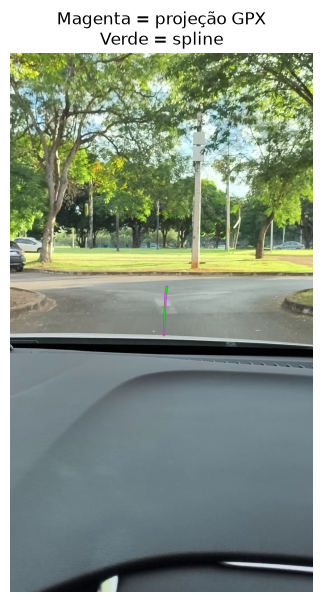

✅ Projeção concluída


In [46]:
# ============================================================
# CÉLULA 6 - Projeção da trajetória GPX usando calibração
# ============================================================

from scipy.interpolate import splprep, splev

# ------------------------------------------------------------
# ENU -> sistema do veículo
# X = frente
# Y = esquerda
# ------------------------------------------------------------

def enu_to_vehicle(de, dn, psi):
    x = np.cos(psi) * dn + np.sin(psi) * de
    y = np.sin(psi) * dn - np.cos(psi) * de
    return x, y


# ------------------------------------------------------------
# GPX -> pixels
# ------------------------------------------------------------

def project_future_path(df_future, frame_row):

    psi = frame_row["heading"]

    xv = []
    yv = []

    for _, p in df_future.iterrows():

        x, y = enu_to_vehicle(
            p["de"],
            p["dn"],
            psi
        )

        if x > 0.3:
            xv.append(x)
            yv.append(y)

    xv = np.asarray(xv)
    yv = np.asarray(yv)

    if len(xv) < 4:
        print("Poucos pontos.")
        return []

    # ordenar

    idx = np.argsort(xv)

    xv = xv[idx]
    yv = yv[idx]

    # remover repetidos

    xv, ind = np.unique(xv, return_index=True)
    yv = yv[ind]

    spline = CubicSpline(
        xv,
        yv,
        bc_type="natural"
    )

    x_dense = np.linspace(
        xv.min(),
        xv.max(),
        120
    )

    y_dense = spline(x_dense)

    vehicle_pts = np.column_stack([
        x_dense,
        y_dense
    ])

    

    img = vehicle_to_image(vehicle_pts)

    pixels = []

    for (u, v), x in zip(img, x_dense):

        u = int(round(u))
        v = int(round(v))

        if not (0 <= u < W_img):
            continue    

        if not (0 <= v < H_img):
            continue

        if road_mask[v, u] == 0:
            continue

        pixels.append((u, v))

    return pixels


# ------------------------------------------------------------
# suavização em pixels
# ------------------------------------------------------------

def smooth_pixels(points):

    if len(points) < 5:
        return points

    pts = np.asarray(points)

    try:

        tck, _ = splprep(
            [pts[:,0], pts[:,1]],
            s=25
        )

        u = np.linspace(0,1,150)

        xs, ys = splev(u, tck)

        return list(zip(xs,ys))

    except:

        return points


# ------------------------------------------------------------
# executar
# ------------------------------------------------------------

raw_pixels = project_future_path(
    df_future,
    frame_row
)

print(f"Pontos projetados : {len(raw_pixels)}")

smooth = smooth_pixels(raw_pixels)

print(f"Pontos suavizados : {len(smooth)}")


# ------------------------------------------------------------
# diagnóstico
# ------------------------------------------------------------

debug = frame_orig.copy()

for u, v in raw_pixels:

    cv2.circle(
        debug,
        (int(u), int(v)),
        4,
        (255,0,255),
        -1
    )

for u, v in smooth:

    cv2.circle(
        debug,
        (int(u), int(v)),
        2,
        (0,255,0),
        -1
    )

plt.figure(figsize=(5, 7))

plt.imshow(cv2.cvtColor(debug,cv2.COLOR_BGR2RGB))

plt.title(
    "Magenta = projeção GPX\n"
    "Verde = spline"
)

plt.axis("off")

plt.show()

print("✅ Projeção concluída")

## 🎨 Célula 7 — Renderizar resultado final

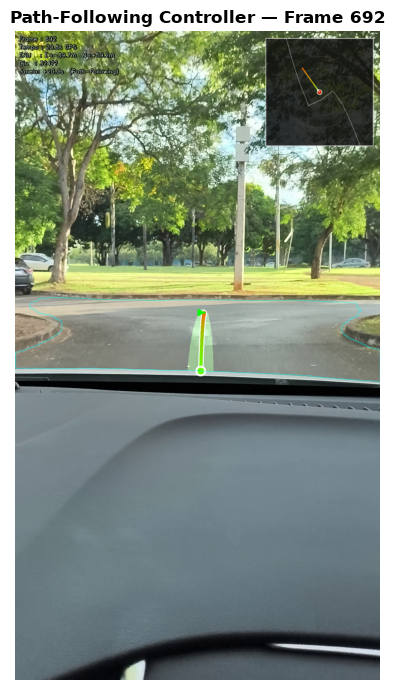

✅ Salvo em c:\Users\Pedro\pibic 26_27\output_yolop_frame/frame_000692_rota.jpg


In [47]:
def draw_trajectory_minimap(frame, df_full_trajectory, df_future, frame_row,
                             color_start, color_end, size=320, margin=20,
                             zoom_radius=40.0, supersample=3, alpha=0.85):
    """
    Mini-mapa da trajetória, com zoom local (centrado no veículo) e
    renderizado em super-resolução para ficar nítido após o downscale.
    """
    h_img, w_img = frame.shape[:2]

    # ----------------------------------------------------
    # Renderiza em resolução maior (supersampling) para nitidez
    # ----------------------------------------------------
    R = size * supersample
    minimap = np.zeros((R, R, 3), dtype=np.uint8)
    cv2.rectangle(minimap, (0, 0), (R-1, R-1), (16, 16, 16), -1)

    # ----------------------------------------------------
    # Zoom local: centraliza no veículo, não na rota inteira
    # ----------------------------------------------------
    e_c, n_c = frame_row['east'], frame_row['north']
    max_range = zoom_radius * 2
    pad = int(18 * supersample)
    scale = (R - 2 * pad) / max_range

    def enu_to_mm(e, n):
        return (int(R/2 + (e - e_c) * scale),
                int(R/2 - (n - n_c) * scale))

    # Anéis de referência de distância (10/20/30 m)
    for d in (10, 20, 30):
        r_px = int(d * scale)
        if r_px < R/2:
            cv2.circle(minimap, (int(R/2), int(R/2)), r_px, (45, 45, 45), max(1, supersample-1), cv2.LINE_AA)

    # Trajetória completa (percorrida), em cinza
    pts_g = [enu_to_mm(r['east'], r['north']) for _, r in df_full_trajectory.iterrows()]
    for i in range(1, len(pts_g)):
        cv2.line(minimap, pts_g[i-1], pts_g[i], (120, 120, 120), max(1, 2*supersample-2), cv2.LINE_AA)

    # Rota futura, colorida com gradiente
    pts_a = [enu_to_mm(r['east'], r['north']) for _, r in df_future.iterrows()]
    for i in range(1, len(pts_a)):
        t   = i / len(pts_a)
        col = lerp_color(color_start, color_end, t)
        cv2.line(minimap, pts_a[i-1], pts_a[i], col, 3*supersample, cv2.LINE_AA)

    # Marcador do veículo
    xe, ye = enu_to_mm(frame_row['east'], frame_row['north'])
    cv2.circle(minimap, (xe, ye), 5*supersample, (0, 0, 255), -1, cv2.LINE_AA)
    cv2.circle(minimap, (xe, ye), 7*supersample, (255, 255, 255), max(1, supersample), cv2.LINE_AA)

    # Seta indicando o heading do veículo
    h = frame_row['heading']
    arrow_len = 12 * supersample
    hx = int(xe + arrow_len * np.sin(h))
    hy = int(ye - arrow_len * np.cos(h))
    draw_arrow(minimap, (xe, ye), (hx, hy), (255, 255, 255), thickness=max(1, supersample), arrow_size=6*supersample)

    # ----------------------------------------------------
    # Downscale com INTER_AREA (nítido, sem serrilhado)
    # ----------------------------------------------------
    minimap = cv2.resize(minimap, (size, size), interpolation=cv2.INTER_AREA)
    cv2.rectangle(minimap, (0, 0), (size-1, size-1), (210, 210, 210), 2, cv2.LINE_AA)

    # ----------------------------------------------------
    # Composição pouco transparente para manter nitidez
    # ----------------------------------------------------
    px, py = w_img - size - margin, margin
    roi = frame[py:py+size, px:px+size]
    cv2.addWeighted(roi, 1 - alpha, minimap, alpha, 0, dst=roi)
    return frame


def render_route_on_frame(
        frame,
        smooth_pixels,
        road_mask,
        color_start,
        color_end,
        line_width,
        fill_alpha):

    result = frame.copy()

    if len(smooth_pixels) < 2:
        return result

    overlay = np.zeros_like(result)

    pts = np.asarray(smooth_pixels, dtype=np.float32)

    # ----------------------------------------------------
    # corredor
    # ----------------------------------------------------

    left = []
    right = []

    for i in range(len(pts)):

        if i == 0:
            dx = pts[i+1,0]-pts[i,0]
            dy = pts[i+1,1]-pts[i,1]

        elif i == len(pts)-1:

            dx = pts[i,0]-pts[i-1,0]
            dy = pts[i,1]-pts[i-1,1]

        else:

            dx = pts[i+1,0]-pts[i-1,0]
            dy = pts[i+1,1]-pts[i-1,1]

        n = np.hypot(dx,dy)

        if n < 1:
            continue

        dx /= n
        dy /= n

        nx = -dy
        ny = dx

        largura = 28*(1-i/len(pts))+10

        left.append([
            pts[i,0]+nx*largura,
            pts[i,1]+ny*largura
        ])

        right.append([
            pts[i,0]-nx*largura,
            pts[i,1]-ny*largura
        ])

    poly = np.vstack([
        left,
        right[::-1]
    ]).astype(np.int32)

    cv2.fillPoly(
        overlay,
        [poly],
        (70,200,90)
    )

    overlay[road_mask==0]=0

    result=cv2.addWeighted(
        result,
        1,
        overlay,
        fill_alpha,
        0
    )

    # ----------------------------------------------------
    # linha branca
    # ----------------------------------------------------

    pts_int=np.int32(pts)

    cv2.polylines(
        result,
        [pts_int],
        False,
        (255,255,255),
        line_width+6,
        cv2.LINE_AA
    )

    # ----------------------------------------------------
    # linha colorida
    # ----------------------------------------------------

    for i in range(1,len(pts_int)):

        cor=lerp_color(
            color_start,
            color_end,
            i/len(pts_int)
        )

        cv2.line(
            result,
            tuple(pts_int[i-1]),
            tuple(pts_int[i]),
            cor,
            line_width,
            cv2.LINE_AA
        )

    # ----------------------------------------------------
    # marcador início
    # ----------------------------------------------------

    p0=tuple(pts_int[0])

    cv2.circle(result,p0,16,(255,255,255),-1)
    cv2.circle(result,p0,10,color_start,-1)

    # ----------------------------------------------------
    # seta final
    # ----------------------------------------------------

    if len(pts_int)>=2:

        draw_arrow(
            result,
            tuple(pts_int[-2]),
            tuple(pts_int[-1]),
            (0,255,0),
            thickness=5,
            arrow_size=22
        )

    return result


def add_hud(frame, frame_row, frame_idx, look_ahead_s):
    result = frame.copy()
    h_deg  = np.rad2deg(frame_row['heading']) % 360
    lines  = [
        f'Frame : {frame_idx}',
        f'Tempo : {frame_row["t_sec"]:.1f}s GPS',
        f'ENU   : E={frame_row["east"]:+.1f}m  N={frame_row["north"]:+.1f}m',
        f'Dir.  : {h_deg:.0f}°',
        f'Janela: +{look_ahead_s:.1f}s  (Path-Following)',
    ]
    for i, line in enumerate(lines):
        y = 28 + i * 24
        cv2.putText(result, line, (11, y), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0,0,0),       3, cv2.LINE_AA)
        cv2.putText(result, line, (10, y), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (220,255,220), 1, cv2.LINE_AA)
    return result


# ── Pipeline ─────────────────────────────────────────────────
result_frame = render_route_on_frame(
    frame_orig, smooth, road_mask,
    color_start  = ROUTE_COLOR_START,
    color_end    = ROUTE_COLOR_END,
    line_width   = ROUTE_LINE_WIDTH,  
    fill_alpha   = ROUTE_ALPHA,
)

# Contorno ciano da máscara
contours, _ = cv2.findContours(road_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
camada = result_frame.copy()
cv2.drawContours(camada, contours, -1, (255,255,0), 2)
cv2.addWeighted(camada, 0.4, result_frame, 0.6, 0, dst=result_frame)

# Mini-mapa (zoom local no veículo, renderizado em super-resolução)
result_frame = draw_trajectory_minimap(
    result_frame, df_gps, df_future, frame_row,
    ROUTE_COLOR_START, ROUTE_COLOR_END, size=320,
    zoom_radius=40.0, supersample=3, alpha=0.85,
)

result_frame = add_hud(result_frame, frame_row, TARGET_FRAME, LOOK_AHEAD_SECONDS)

# Salvar
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
out_path = f'{OUTPUT_DIR}/frame_{TARGET_FRAME:06d}_rota.jpg'
cv2.imwrite(out_path, result_frame, [cv2.IMWRITE_JPEG_QUALITY, 95])

plt.figure(figsize=(5, 7))
plt.imshow(cv2.cvtColor(result_frame, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f'Path-Following Controller — Frame {TARGET_FRAME}', fontweight='bold')
plt.tight_layout()
plt.show()
print(f'✅ Salvo em {out_path}')
